---
title: "3D Forward Simulation for Sheet-Like Conductors"
authors:
  - id: devincowan
---

**TODO:**

* plate utilities need to be added to SimPEG
* plate utilities need to be imported from SimPEG
* links to plate utility functions need to be added to tutorial
* eventually, we won't use sigma or tau as physical properties

```{admonition} Advanced notebook
:class: danger
This tutorial focusses on advanced functionality within SimPEG. Basic and intermediate level functionality are not discussed in detail, as we assume the user is already an experienced SimPEG user.
```

```{admonition} Medium-weight notebook
:class: caution
Requires moderate computational resources. Run-times may exceed several minutes and require up to 8 GB of available RAM.
```

```{admonition} Prerequisite Tutorials
:class: note
* [Fundamentals of Finite Volume for TDEM Simulations](fwd_tdem_fundamentals.ipynb
* [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb)
```

**Keywords:** Forward simulation, hierarchical finite volume, sheet-like conductors.

</br>

**Summary:** In this tutorial, we demonstrate a 3D hierarchical finite volume approach for simulating the TDEM responses from sheet-like conductors in a complex host. We consider borehole UTEM data simulated for a rectangular plate conductor and for an inhomogeneous sheet-like conductor. Since many of the steps in this tutorial repeat the contents of the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial, please work through that one before working through this one. Functionality used to simulate the data is imported from the [simpeg.electromagnetics.time_domain](xref:simpeg#simpeg.electromagnetics.time_domain) module.

The hierarchical finite volume approach works by parameterizing less conductive large-scale structures as cell conductivities ($\sigma$), sheet-like conductors as face conductances ($\xi_x, \xi_y, \xi_z$), and wire-like conductors as edge integrated conductances ($\lambda_x, \lambda_y, \lambda_z$).

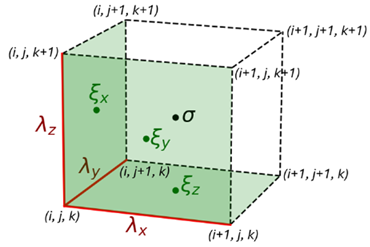



</br>

**Learning Objectives:**

- Introducing the hierarchical simulation class for 3D TDEM problems
- Defining the model parameters
- Simulating data for sheet-like conductors
- Designing appropriates meshes

## Importing Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to TDEM is imported from [simpeg.electromagnetics.time_domain](xref:simpeg#simpeg.electromagnetics.time_domain).
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils).

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from simpeg.utils import plot2Ddata, get_default_solver

# discretize functionality
from discretize import TreeMesh, SimplexMesh
from discretize.utils import mkvc, ndgrid, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.spatial import Delaunay, cKDTree
from scipy.interpolate import LinearNDInterpolator
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection




import sys, os
sys.path.append(r"D:\Documents\Python\my_supporting_functions")
from my_plate_utils import (
    maxwell_plate_to_nodes,
    dipping_plate_to_nodes,
    get_face_indices_plate,
    get_face_projection_simplex,
)
from my_field_utils import computeH0

mpl.rcParams.update({"font.size": 14})

write_output = False  # Optional

## Define the Topography

Here, we reuse the valley-like topography from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb).

In [2]:
# Generate or load topography
x_topo, y_topo = np.meshgrid(
    np.linspace(-2100, 2100, 141), np.linspace(-2100, 2100, 141)
)
z_topo = 300.0 + 100.0 * (1 / np.pi) * (
    np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) - 1000.0) / 300.0)
    - np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) + 1000.0) / 300.0)
)

In [3]:
# Turn into a (N, 3) numpy.ndarray
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]

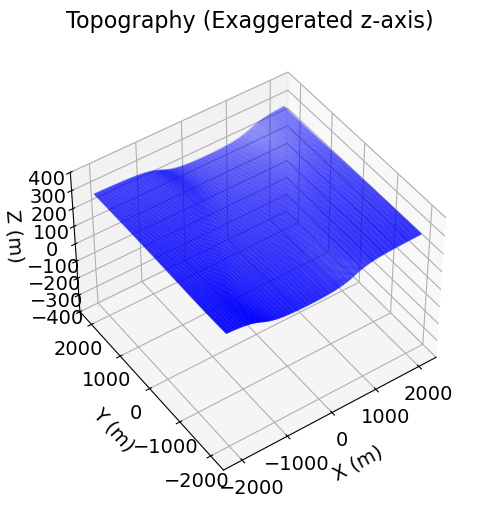

In [4]:
# Plot the topography
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.25, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)

## Define the Survey

The objects required to define a TDEM survey within SimPEG are provided in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

**For this tutorial**, we simulate borehole University of Toronto electromagnetic (UTEM) data for a single transmitter loop. Some basic information regarding UTEM survey geometry and its data can be found [here](https://giftoolscookbook.readthedocs.io/en/latest/content/comprehensive_workflow/utem/1_basic_anomalies.html). The transmitter loop is square with a side length of 1200 m. The period of the UTEM waveform is 1 s. db/dt sensors located within the loop are used to measure 3-component data for a highly-regulated triangular waveform with a 100% duty cycle. Fiels are measured within a borehole at (x, y) = (80 m, 20 m) that extends 800 m vertical below the Earth's surface.

#### Defining Survey Parameters

In [5]:
# WAVEFORM PROPERTIES
period = 1.0  # Period
I_max = 1.0  # Maximum current amplitude

# TRANSMITTER LOOP PROPERTIES
loop_width = 1200

# RECEIVER LOCATIONS
x_bh, y_bh = 80., 20.           # horizontal position
ds = 25.0                       # receiver spacing
s_max = topo_xyz[:, -1].min()   # top receiver
s_min = s_max - 800.            # bottom receiver

# TIME CHANNELS
time_channels = 0.25 * period * 2 ** np.linspace(-7, 0, 8)

#### Defining the Waveform

We use the same waveform that was used in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. The [BaseWaveform](xref:simpeg#simpeg.electromagnetics.time_domain.sources.RawWaveform) class is used to define the highly regulated 100\% duty cycle triangular waveform. Where $T$ is the waveform period, the waveform will be defined from $-3T/4$ to $T/4$. We plot the full waveform and time channels below.

In [6]:
slope = 4 / period

# Function handle
def wave_fun(t):
    ta, tb = -0.5 * period, 0.0
    w = (
        np.heaviside(ta - t, 0.5) * (slope * t + 3.0 * I_max)
        + np.heaviside(t - ta, 0.5) * np.heaviside(tb - t, 0.5) * (-slope * t - I_max)
        + np.heaviside(t - tb, 0.5) * (slope * t - I_max)
    )
    return w

# Define the waveform
general_waveform = tdem.sources.RawWaveform(
    off_time=period / 2, waveform_function=wave_fun
)

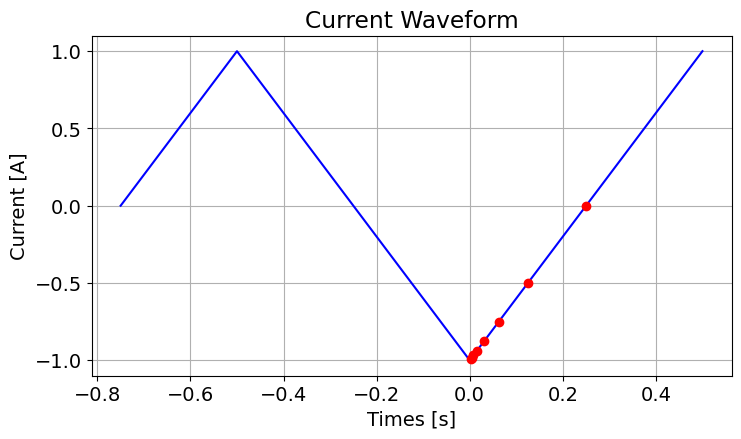

In [7]:
fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.85])
plot_times = np.linspace(-3 * period / 4, period / 2.0, 26)
ax1.plot(plot_times, wave_fun(plot_times), "b")
ax1.plot(time_channels, wave_fun(time_channels), "ro")
ax1.grid()
ax1.set_xlabel("Times [s]")
ax1.set_ylabel("Current [A]")
ax1.set_title("Current Waveform")

plt.show()

#### Defining the Source, Receiver and Survey Objects

We use the same approach for generating the survey as was demonstrated in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. The same transmitter loop, receiver type, and time channels are used. However, the locations and orientations of the field measurements are different.

**For this tutorial,** field are measured for a set of borehole receivers. Instead of simulating 3-component data along the X, Y and Z directions, we simulate the fields using a borehole-centric coordinate system:
* *Strike direction (U):* which in this case is in the Northing direction
* *Dip direction (V):* which in this case is in the Easting direction
* *Downhole direction (A):* which in this case is in the down direction

```{admonition} Note
:class: note
For real-world problems, boreholes are not perfectly vertical, as resolving near-vertical borehole orientation becomes challenging.
``` 

In [8]:
# Necessary to define transmitter on surface topography
topo_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)

In [9]:
# Define the transmitter loop using 50 m segments
half_width = 0.5 * loop_width
u = np.arange(-half_width, half_width, 50.0)
v = half_width * np.ones_like(u)

xtx = np.r_[u, v, -u, -v, -half_width]
ytx = np.r_[-v, u, v, -u, -half_width]
ztx = topo_interp(np.c_[xtx, ytx])
xyz_loop = np.c_[xtx, ytx, ztx]

In [10]:
# Define the borhole receiver locations
z_bh = np.arange(s_min, s_max+ds, ds)
receiver_locations = ndgrid(x_bh, y_bh, z_bh)

In [11]:
# Define the orientations for the U, V and A receivers
orientations_list = [
    np.r_[0, 1, 0],
    np.r_[1, 0, 0],
    np.r_[0, 0, -1]
]

# Define U, V, A receivers
receivers_list = [
    tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_locations, time_channels, orientation=orient
    ) for orient in orientations_list
]

# Define the loop source
source_list = [
    tdem.sources.LineCurrent(
        receivers_list, location=xyz_loop, waveform=general_waveform
    )
]

# Define the survey
survey = tdem.Survey(source_list)

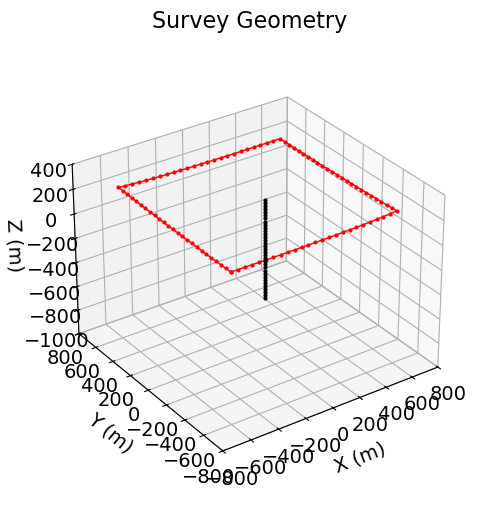

In [61]:
# Plot the survey geometry
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_xlim([-800, 800])
ax.set_ylim([-800, 800])
ax.set_zlim([-1000, 400])
ax.plot(xyz_loop[:, 0], xyz_loop[:, 1], xyz_loop[:, 2], "r-o", lw=1, markersize=2)
ax.plot(
    receiver_locations[:, 0],
    receiver_locations[:, 1],
    receiver_locations[:, 2],
    "k-o",
    lw=1,
    markersize=2
)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Survey Geometry", fontsize=16, pad=-20)
ax.view_init(elev=30.0, azim=-125)

## Define the Time Discretization

Here, we use the time discretization from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb). The time discretization is illustrated below.

In [13]:
n_steps = 20
min_dt = time_channels[0] / 20.0
min_dt = round(min_dt, 1 - int(np.floor(np.log10(min_dt))) - 1)

tc_min = np.min(time_channels)
tc_max = np.max(time_channels)
ti = [None, tc_min, 6 * tc_min, 36 * tc_min]
dt = [period / 60, min_dt, 6 * min_dt, 36 * min_dt]

In [14]:
wave_times = np.arange(-0.75 * period, 0, dt[0])

wave_times = np.r_[wave_times, np.arange(0, ti[1] + dt[1], dt[1])]
wave_times = np.r_[wave_times, np.arange(wave_times[-1] + dt[2], ti[2] + dt[2], dt[2])]
wave_times = np.r_[wave_times, np.arange(wave_times[-1] + dt[3], ti[3] + dt[3], dt[3])]
wave_times = np.r_[
    wave_times, np.arange(wave_times[-1] + dt[0], tc_max + 2 * dt[0], dt[0])
]

In [15]:
time_steps = np.diff(wave_times)  # Time steps
t0 = wave_times[0]  # Initial time for the simulation

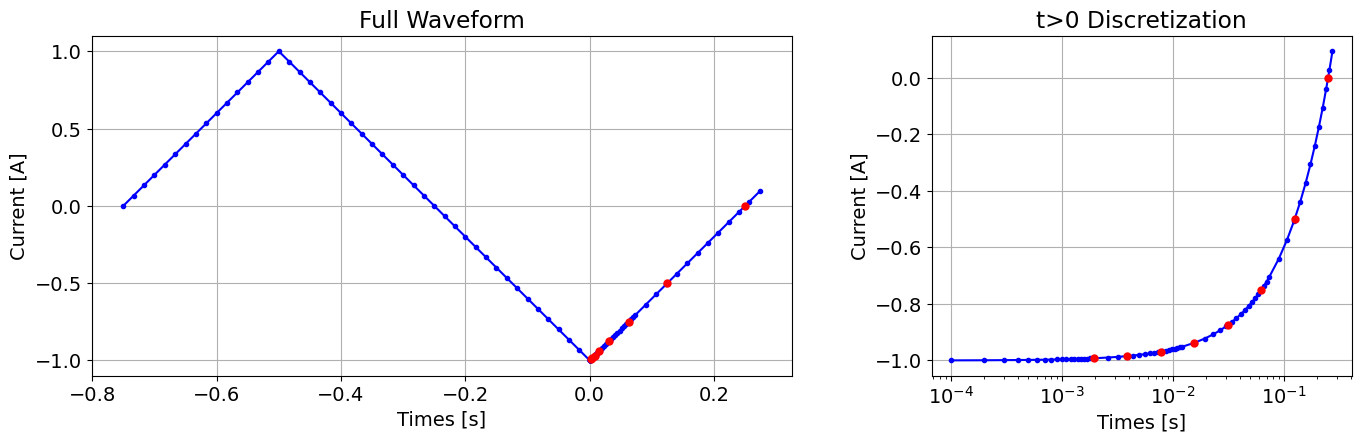

In [16]:
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_axes([0.1, 0.1, 0.5, 0.85])
ax1.plot(wave_times, wave_fun(wave_times), "b-o", markersize=3)
ax1.plot(time_channels, wave_fun(time_channels), "ro", markersize=5)
ax1.grid()
ax1.set_xlabel("Times [s]")
ax1.set_ylabel("Current [A]")
ax1.set_title("Full Waveform")

ax2 = fig.add_axes([0.7, 0.1, 0.3, 0.85])
plot_times = np.logspace(np.log10(time_channels.min()), np.log10(time_channels.max()))
k = wave_times > 0.0
ax2.semilogx(wave_times[k], wave_fun(wave_times[k]), "b-o", markersize=3)
ax2.semilogx(time_channels, wave_fun(time_channels), "ro", markersize=5)
ax2.grid()
ax2.set_xlabel("Times [s]")
ax2.set_ylabel("Current [A]")
ax2.set_title("t>0 Discretization")

plt.show()

## Define a (Tree) Mesh

In the tutorial [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb), we designed our mesh according to the rules of thumb provided in the [Fundamentals of Finite Volume for TDEM Simulations](fwd_tdem_fundamentals.ipynb) tutorial. Discretization throughout the mesh was determined by diffusion distances and proximity to the wire transmitter. These rules still apply since we need to accurately capture the electromagnetic fields related to larger-scale structures throughout the modeling domain.

When designing a mesh to simulate sheet-like conductors, we must also consider:

1. the smoothness of the primary electromagnetic field over the sheet-like conductor
2. the smoothness of the currents over the sheet-like conductor
3. the smoothness of the secondary magnetic fields produced by the sheet-like conductor
4. the locations of the receivers relative to the margins of the sheet-like conductor

The parameterization of a sheet-like conductor onto an OcTree mesh aims to preserve the flux integrated over the surface of that sheet-like conductor. This isn't overly problematic if the sheet-like conductor is far from a controlled source. Finer discretization may be required when a partion of a sheet-like conductor close to a controlled source. Use a cell size so that the sheet-like conductor is at least 3-4 cells away from the transmitter.

The optimum discretization in the region of a sheet-like conductor is highly subjective. For rectangular conductors, the widths should be at least 8-10 cells wide to capture induced eddy currents. Finer cells may be required for sheet-like structures that are electrically inhomogeneous or have complex shape. The cell width chosen to discretize about the sheet-like conductor should extend at least 4-6 cells away from the conductor to capture the secondary electromagnetic fields. It is especially important to capture the electromagnetic fields at the edges of sheet-like conductors.

The parameterization of a sheet-like conductor onto a structured (e.g. OcTree) mesh produces large numerical errors close to the sheet-like conductor. Numerical accuracy is generally reasonable when field measurements are at least 3-4 cell widths away from the parameterized sheet-like conductor. 

**Tutorial mesh:** Here, a minimum cell width of 25 m is used in proximity of the transmitter loop to accurately capture the geometry of the primary field. A minimum cell width of 25 m is used near the receivers to minimize interpolation error. And a minimum cell width of 25 m is used in the region where a sheet-like conductor is modeled in order to capture the diffusion of eddy currents and secondary magnetic fields. A discretization of 50 m is used for the remainder of the survey region. The host has a conductivity of 1e-3 S/m. Since the diffusion distance for the host is so large at the earliest time channel, the cell size within the survey region is more driven by geometry of the primary field. The largest diffusion distance is ~20,000 m. So the width of the padding region was set to 40,000 m in all directions.

In [17]:
air_conductivity = 1e-8
host_conductivity = 1e-3

In [18]:
host_diffusion_distance = 1260 * np.sqrt(time_channels / host_conductivity)
print("HOST: {}".format(host_diffusion_distance))

HOST: [ 1760.90353228  2490.29365738  3521.80706456  4980.58731477
  7043.61412912  9961.17462953 14087.22825825 19922.34925906]


In [19]:
# Instantial OcTree mesh
dh = 25.0
L = 80000.0
nbc = 2 ** int(np.round(np.log(L / dh) / np.log(2.0)))
h = [(dh, nbc)]
mesh = TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# Shift vertically so top same as maximum topography
mesh.origin += np.r_[0.0, 0.0, z_topo.min()]

In [20]:
# Discretize around transmitter
n_seg = np.shape(xyz_loop)[0] - 1
n_pts_per_seg = 20

pts = [
    np.c_[
        np.linspace(xyz_loop[ii, 0], xyz_loop[ii + 1, 0], n_pts_per_seg),
        np.linspace(xyz_loop[ii, 1], xyz_loop[ii + 1, 1], n_pts_per_seg),
        np.linspace(xyz_loop[ii, 2], xyz_loop[ii + 1, 2], n_pts_per_seg),
    ]
    for ii in range(n_seg)
]

pts = np.vstack(pts)
mesh.refine_points(pts, level=-1, padding_cells_by_level=[4, 3, 2, 2], finalize=False)

In [21]:
# Discretize around borehole receivers
mesh.refine_points(receiver_locations, level=-1, padding_cells_by_level=[3, 3], finalize=False)

In [22]:
# Discretization for core survey region
pts = ndgrid(
    np.r_[-700, 700], np.r_[-700, 700], np.r_[z_topo.min() - 800, z_topo.min() + 50]
)

mesh.refine_bounding_box(pts, -2, padding_cells_by_level=[0, 4, 4], finalize=False)

In [23]:
# Discretize surface topography
inds = (np.abs(topo_xyz[:, 0]) < 1400.0) & (np.abs(topo_xyz[:, 1]) < 1400.0)

mesh.refine_surface(
    topo_xyz[inds, :], -2, padding_cells_by_level=[1, 2], finalize=False
)

In [24]:
# Discretize in the region of the sheet-like conductor
pts = ndgrid(
    np.r_[-300, 300], np.r_[-300, 300], np.r_[-400, 0]
)

mesh.refine_bounding_box(pts, -1, padding_cells_by_level=[0, 4, 4], finalize=False)

In [25]:
mesh.finalize()

In [26]:
mesh.n_cells

77897

## Define the Background Conductivity

Here, we define the cell conductivities that parameterize all large-scale less conductive structures within the modeling domain. By adopting the term 'background conductivity', we are stating that the cell conductivities are fixed parameters in the forward simulation. And our model (defined later) consists of the parameters defining a sheet-like conductor. **For this tutorial,** all cells below the discrete surface topography are assigned a conductivity of 1e-3 S/m and all air cells are assigned a conductivity of 1e-8 S/m. So, the background conductivity is an (n_cells,) [numpy.ndarray](xref:numpy#numpy.ndarray).

```{admonition} Complex background conductivity
:class: note
The hierarchical finite volume approach allows complete freedom to include 3D structure in the background conductivity. We are not limited to a homogeneous background.
```

```{admonition} Including conductivity in the model
:class: note
Cell conductivities can be included in the model. However, the model would contain two parameter types and the user must construct an appropriate mapping for multiple hierarchical electrical properties. Furthermore, the inclusion of cell conductivities within an inversion scheme would make the problem even more under-determined.
```

In [27]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

# Define the background conductivity (n_cells,)
background_conductivity = air_conductivity * np.ones(mesh.n_cells)
background_conductivity[active_cells] = host_conductivity

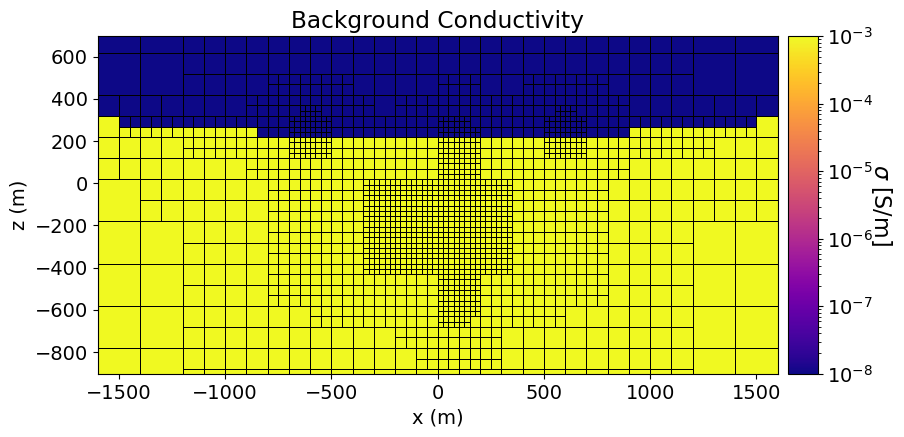

In [69]:
# Plot the background conductivity
fig = plt.figure(figsize=(10, 4.5))

norm = LogNorm(vmin=background_conductivity.min(), vmax=background_conductivity.max())

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    background_conductivity,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    grid_opts={"lw": 0.5, "color": 'k'}
)
ax1.set_title("Background Conductivity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([-1600, 1600])
ax1.set_ylim([z_topo.max() - 1200, z_topo.max() + 400])

ax2 = fig.add_axes([0.84, 0.15, 0.03, 0.75])
cbar = mpl.colorbar.ColorbarBase(
    ax2, cmap=mpl.cm.plasma, norm=norm, orientation="vertical"
)
cbar.set_label(r"$\sigma$ [S/m]", rotation=270, labelpad=15, size=16)

## Plate Conductor Simulation

Here, we simulate borehole UTEM data for a dipping rectangular plate conductor within a background conductivity.

### Defining Plate Properties

We start by defining the properties for the dipping plate conductor we want to model. **For this tutorial,** the plate is square with a side length of 500 m and a conductance of 1000 S/m. The plate is centered at (0, 0, -200), strikes to the North, and dips 30 degrees to the East. Since users may be more familiar with using programs such as Maxwell, we have added the option to define the plate according to the PTE format.

In [88]:
use_pte = True

if use_pte:
    east = -216.5             # hinge point (Easting)
    north = 0.                # hinge point (Northing)
    level = -75.              # hinge point (Elevation)
    dip_angle = 30.           # dip (degrees)
    dip_direction = 90        # dip direction (CW from Northing)
    plunge_angle = 0.         # plunge (degrees)
    length = 500.             # strike length (m)
    depth_extent = 500.       # dip length (m)
    plate_conductance = 1000. # conductance (S)
else:
    plate_center = np.r_[0, 0, -200]  # plate center (x,y,z)
    strike_width = 500.               # width along strike (m)
    dip_width = 500.                  # width along dip (m)
    strike_angle = 0.                 # strike angle (degrees)
    dip_angle = 30.                   # dip angle (degrees)
    plunge_angle = 0.                 # plunge angle (degrees)
    plate_conductance = 1000.         # conductance (S)

### Plate Model and Mapping

The hierarchical finite volume approach simulates TDEM fields by representing sheet-like conductors as conductances that live on mesh faces. Instead of trying to map the set of plate properties to the faces of the mesh, our model parameters will represent the face conductances for all mesh faces. The discrete set of faces that best approximate the plate are assigned a value equal to the conductance of the plate (e.g. 1000 S). All other faces are assigned a parameter value of 0.

**Mapping:** SimPEG requires that we define a mapping between the set of model parameters to all mesh faces. Since the model parameters are the conductances for all mesh faces, we use the [simpeg.maps.IdentityMap](xref:simpeg#simpeg.maps.IdentityMap) class. **However,** we must make sure to manually set the number of parameters *nP* to equal the number of mesh faces!!!

In [76]:
plate_conductance_map = maps.IdentityMap(nP=mesh.n_faces)

**Finding the mesh faces:** We now need to find a set of mesh faces that best represent the dipping plate conductor. We do this in 2 steps. First, we use either the ``maxwell_plate_to_nodes`` or ``dipping_plate_to_nodes`` utility to recover the nodes which define the corners of the plate. Next, we use the ``get_face_indices_plate`` utility to obtain the indices of the mesh faces that best represent the plate. As we will see shortly, this results in a step-like approximation for structured (e.g. OcTree) meshes.

In [77]:
# Recover the nodes of the plate
if use_pte:
    plate_nodes = maxwell_plate_to_nodes(
        east,
        north,
        level,
        dip_angle,
        dip_direction,
        plunge_angle,
        length,
        depth_extent
    )
else:
    plate_nodes = dipping_plate_to_nodes(
        plate_center = np.r_[0, 0, -200],
        strike_width = 500.,
        dip_width = 500.,
        strike_angle = 0.,
        dip_angle = 30.,
        plunge_angle = 0.
    )

# Get the active plate indices
face_inds_plate = get_face_indices_plate(mesh, plate_nodes)

Finally, we define the face conductances model for the dipping rectangular plate.

In [79]:
# Instantiate as a (n_faces,) vector of zeros
plate_conductance_model = np.zeros(mesh.n_faces)

# Assign conductance to all plate cells
plate_conductance_model[face_inds_plate] = plate_conductance

The original geometry of the plate and the faces that best represent the plate on an OcTree mesh are illustrated below.

```{admonition} Multiple plates
:class: note
Multiple plates can be added by getting the face indices and replacing model parameter values within a for loop.
```

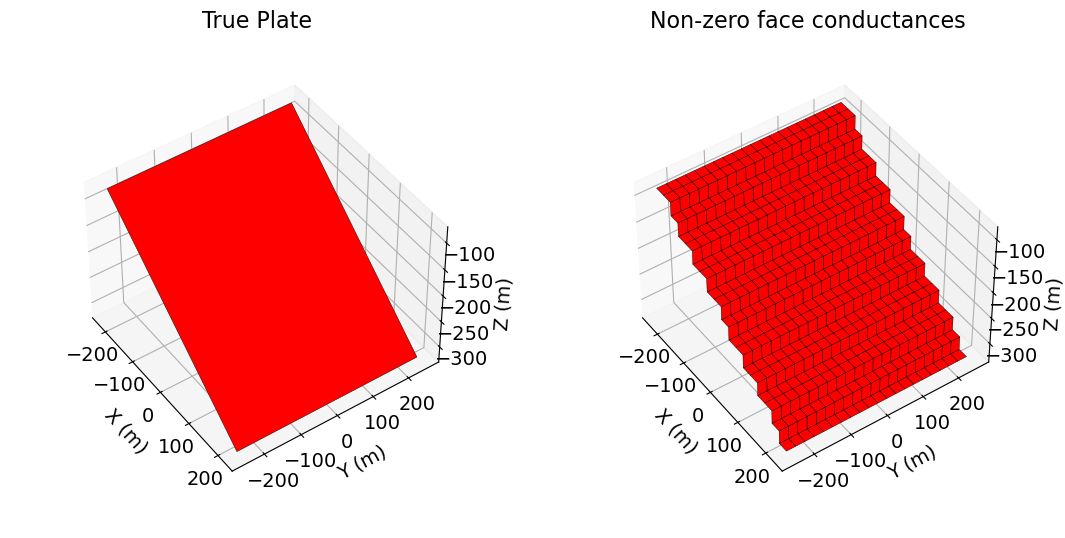

In [86]:
plate_faces = mesh.faces[face_inds_plate, :]
plate_normals = mesh.face_normals[face_inds_plate, :]
n_plate_faces = sum(plate_faces)

poly_pts = np.expand_dims(plate_faces, axis=1)
poly_pts = np.tile(poly_pts, (1, 4, 1))
for ii, nrml in enumerate(plate_normals):
    if nrml[0] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [0, -1, -1], [0, 1, -1], [0, 1, 1], [0, -1, 1]
        ])
    elif nrml[1] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, 0, -1], [1, 0, -1], [1, 0, 1], [-1, 0, 1]
        ])
    elif nrml[2] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, -1, 0], [1, -1, 0], [1, 1, 0], [-1, 1, 0]
        ])

fig = plt.figure(figsize=(11, 6))
ax1 = fig.add_axes([0.0, 0.1, 0.45, 0.85], projection="3d")
ax2 = fig.add_axes([0.5, 0.1, 0.45, 0.85], projection="3d")

poly_faces = Poly3DCollection(plate_nodes.reshape((1, 4, 3)))
poly_faces.set_facecolor('r')
poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_faces.set_linewidth(0.3)
ax1.add_collection3d(poly_faces)
ax1.set_box_aspect(aspect=None, zoom=0.8)
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_zlabel("Z (m)", labelpad=10)
ax1.set_title("True Plate", fontsize=16, pad=-20)
ax1.view_init(elev=45.0, azim=-35)
             
poly_faces = Poly3DCollection(poly_pts)
poly_faces.set_facecolor('r')
poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_faces.set_linewidth(0.3)
ax2.add_collection3d(poly_faces)
ax2.set_box_aspect(aspect=None, zoom=0.8)
ax2.set_xlabel("X (m)", labelpad=10)
ax2.set_ylabel("Y (m)", labelpad=10)
ax2.set_zlabel("Z (m)", labelpad=10)
ax2.set_title("Non-zero face conductances", fontsize=16, pad=-20)
ax2.view_init(elev=45.0, azim=-35)

plt.show()

### Define the Simulation

For hierarchical electrical properties, we cannot use the standard 3D TDEM simulation classes. We must use one of the following classes:

* [Simulation3DHierarchicalElectricField](xref:simpeg#simpeg.electromagnetics.time_domain.simulation.Simulation3DHierarchicalElectricField), which solves for the electric fields on mesh edges.
* [Simulation3DHierarchicalMagneticFlux](xref:simpeg#simpeg.electromagnetics.time_domain.simulation.Simulation3DHierarchicalMagneticFlux), which solves for the magnetic flux densities on mesh faces.

Since the source is a line current the receivers are measuring db/dt, we will use the electric field formulation. The hierarchical simulation classes allow

* `sigma` or `sigmaMap`: Use `sigma` to set and fix the cell conductivity values in the forward simulation. Use `sigmaMap` to define the mapping if parameters related to cell conductivities are included in the model.
* `tau` or `tauMap`: Use `tau` to set and fix the face conductance values in the forward simulation. Use `tauMap` to define the mapping if parameters related to face conductances are included in the model.
* `kappa` or `kappaMap`: Use `kappa` to set and fix the edge integrated conductance values in the forward simulation. Use `kappaMap` to define the mapping if parameters related to edge integrated conductances are included in the model.

**For the tutorial,** we use `sigma` to set and fix the cell conductivities to the values in our background conductivity. Our model parameters are the face conductances for all mesh faces, so we use `tauMap` to set the mapping. Since wire-like structures are not considered, we do not set `kappa` or `kappaMap`.

In [36]:
simulation_plate = tdem.simulation.Simulation3DHierarchicalElectricField(
    mesh,
    survey=survey,
    sigma=background_conductivity,
    tauMap=plate_conductance_map,
    solver=get_default_solver()
)
simulation_plate.time_steps = time_steps
simulation_plate.t0 = t0

### Predict Data

In [37]:
dpred_plate = simulation_plate.dpred(plate_conductance_model)

### Plot Primary Reduced Data

Here, we plot the primary reduced data. Our method for generating primary reduced data is explained in the  [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

In [38]:
# Define a vacuum background conductivity
vacuum_conductivity = air_conductivity * np.ones_like(background_conductivity)

# Replace the background conductivity in the simulation
simulation_plate.sigma = vacuum_conductivity

# For the vacuum model, all parameter values are 0
vacuum_model = np.zeros(mesh.n_faces)

# Simulate the fields
dpred_0 = simulation_plate.dpred(vacuum_model)

In [39]:
# Reshape predicted data vectors to arrays and convert to b-field representation
n_comp = 3  # Simulated x, y and z components
n_rx = np.shape(receiver_locations)[0]  # number of receiver locations
n_times = len(time_channels)  # number of time channels

b_plate = (period / 4) * np.reshape(dpred_plate, (n_comp, n_times, n_rx))
b_0 = (period / 4) * np.reshape(dpred_0, (n_comp, n_times, n_rx))

In [40]:
# Compute the absolute value of the primary b-field
b_p = computeH0(xyz_loop, receiver_locations)  # list with x, y and z component
b_p = mu_0 * np.sqrt(b_p[0]**2 + b_p[1]**2 + b_p[2]**2)

In [41]:
# Compute primary reduced data for U, V and A directions
u_plate = 100 * (b_plate[0, :, :] - b_0[0, :, :]) / b_p
v_plate = 100 * (b_plate[1, :, :] - b_0[1, :, :]) / b_p
a_plate = 100 * (b_plate[2, :, :] - b_0[2, :, :]) / b_p

data_plate = [u_plate, v_plate, a_plate]

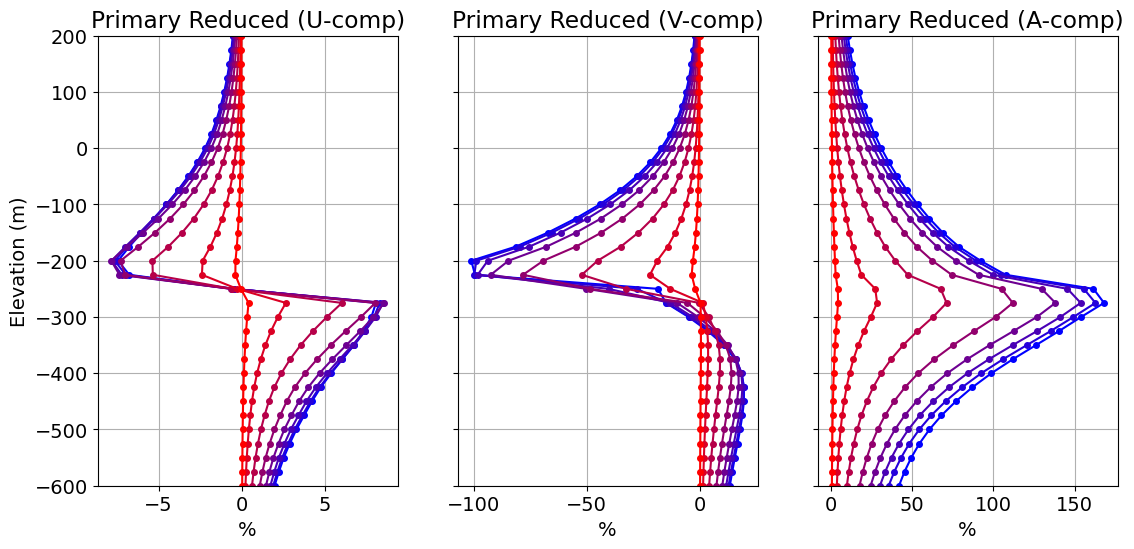

In [42]:
fig = plt.figure(figsize=(12, 6))
ax1 = [fig.add_axes([0.05 + 0.3 * ii, 0.2, 0.25, 0.75]) for ii in range(0, 3)]

comp_list = ["U", "V", "A"]

for ii in range(0, 3):
    d_temp = data_plate[ii]

    for jj in range(n_times):
        ax1[ii].plot(
            d_temp[jj, :],
            receiver_locations[:, 2],
            marker="o",
            color=[jj / (n_times - 1), 0, 1 - jj / (n_times - 1)],
            markersize=4,
            label="_nolegend_",
        )

    ax1[ii].grid()
    ax1[ii].ticklabel_format(axis="both", scilimits=(0, 3))
    ax1[ii].set_xlabel("%")
    ax1[ii].set_ylim([s_min, s_max])
    if ii == 0:
        ax1[ii].set_ylabel("Elevation (m)")
    else:
        ax1[ii].set_yticklabels([])
    ax1[ii].set_title("Primary Reduced ({}-comp)".format(comp_list[ii]))

plt.show(fig)

## Delaunay Surface Simulation

Make a Delaunay surface defined on the xy-plane at z=0

In [43]:
temp_width = 480.
ds = 40.

In [44]:
dlny_pts = ndgrid(
    np.arange(-temp_width/2, temp_width/2+ds, ds),
    np.arange(-temp_width/2, temp_width/2+ds, ds),
    0.
)

dlny_ids = np.arange(len(dlny_pts))

k1 = (dlny_pts[:, 0] < np.max(dlny_pts[:, 0])) & (dlny_pts[:, 1] < np.max(dlny_pts[:, 1]))
k2 = (dlny_pts[:, 0] > np.min(dlny_pts[:, 0])) & (dlny_pts[:, 1] < np.max(dlny_pts[:, 1]))
k3 = (dlny_pts[:, 0] < np.max(dlny_pts[:, 0])) & (dlny_pts[:, 1] > np.min(dlny_pts[:, 1]))
k4 = (dlny_pts[:, 0] > np.min(dlny_pts[:, 0])) & (dlny_pts[:, 1] > np.min(dlny_pts[:, 1]))

dlny_simps = np.vstack([
    np.c_[dlny_ids[k1], dlny_ids[k2], dlny_ids[k3]],
    np.c_[dlny_ids[k2], dlny_ids[k3], dlny_ids[k4]]
])

In [45]:
dlny_centers = np.zeros((len(dlny_simps), 3))
for ii in range(3):
    dlny_centers += dlny_pts[dlny_simps[:, ii], :] / 3.


dlny_conductance_model = 1 + 1e4 * np.exp(
    -(dlny_centers[:, 0] - 20)**2/120**2 - (dlny_centers[:, 1] - 40.)**2/220**2
)

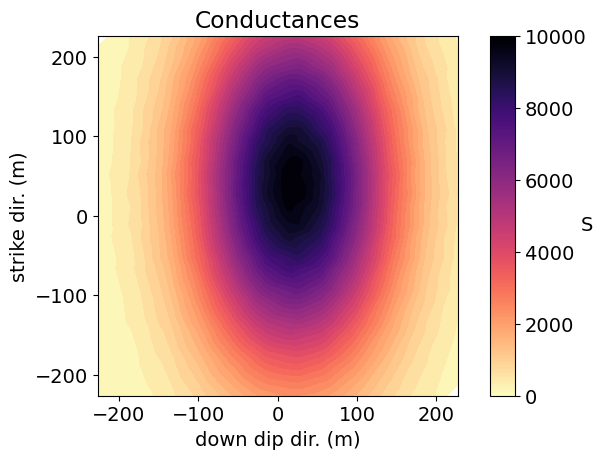

In [46]:
fig = plt.figure(figsize=(5, 4))
ax1 = fig.add_axes([0.05, 0.05, 0.75, 0.9])
ax2 = fig.add_axes([0.85, 0.05, 0.05, 0.9])

cmap = mpl.cm.magma_r
norm = mpl.colors.Normalize(vmin=0, vmax=1e4)
plot2Ddata(
    dlny_centers,
    dlny_conductance_model,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": cmap, "norm": norm},
)
ax1.set_title("Conductances")
ax1.set_xlabel("down dip dir. (m)")
ax1.set_ylabel("strike dir. (m)")


cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.magma_r
)
cbar.set_label("S", rotation=0, labelpad=0)

plt.show()

In [47]:
# Warp the plate with sinusoid
dlny_pts[:, 2] += 100. * np.sin(2 * np.pi * dlny_pts[:, 0] / temp_width)

# Apply rotation matrix to dip it
psi = 30.
psi *= np.pi / 180
A_rot = np.array([
    [1, 0, 0],
    [0, np.cos(psi), np.sin(psi)],
    [0, -np.sin(psi), np.cos(psi)]
])
dlny_pts = np.dot(dlny_pts, A_rot)

# Shift downward
dlny_pts -= np.c_[0, 0, 200]

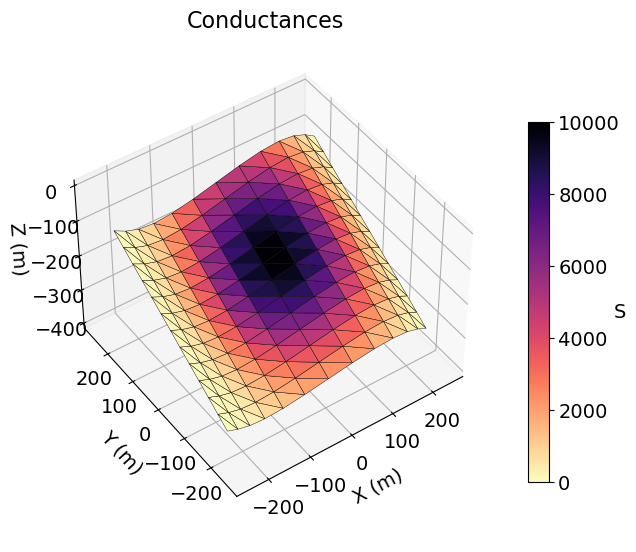

In [48]:
poly_tris = Poly3DCollection(dlny_pts[dlny_simps])
poly_colors = cmap(norm(dlny_conductance_model))
poly_tris.set_facecolor(poly_colors)
poly_tris.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_tris.set_linewidth(0.3)

fig = plt.figure(figsize=(7, 6))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85], projection="3d")
ax2 = fig.add_axes([0.85, 0.2, 0.03, 0.6])

ax1.add_collection3d(poly_tris)
ax1.set_box_aspect(aspect=None, zoom=0.85)
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_zlabel("Z (m)", labelpad=10)
ax1.set_title("Conductances", fontsize=16, pad=-20)
ax1.view_init(elev=45.0, azim=-125)

cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.magma_r
)
cbar.set_label("S", rotation=0, labelpad=0)

plt.show()

### Mapping

In [49]:
P = get_face_projection_simplex(mesh, dlny_pts, dlny_simps)

In [50]:
dlny_conductance_map = maps.LinearMap(A=P)

In [51]:
temp_conds = P @ dlny_conductance_model
temp_inds = temp_conds > 0.

In [52]:
plate_faces = mesh.faces[temp_inds, :]
plate_normals = mesh.face_normals[temp_inds, :]
n_plate_faces = sum(plate_faces)

poly_pts = np.expand_dims(plate_faces, axis=1)
poly_pts = np.tile(poly_pts, (1, 4, 1))
for ii, nrml in enumerate(plate_normals):
    if nrml[0] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [0, -1, -1], [0, 1, -1], [0, 1, 1], [0, -1, 1]
        ])
    elif nrml[1] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, 0, -1], [1, 0, -1], [1, 0, 1], [-1, 0, 1]
        ])
    elif nrml[2] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, -1, 0], [1, -1, 0], [1, 1, 0], [-1, 1, 0]
        ])

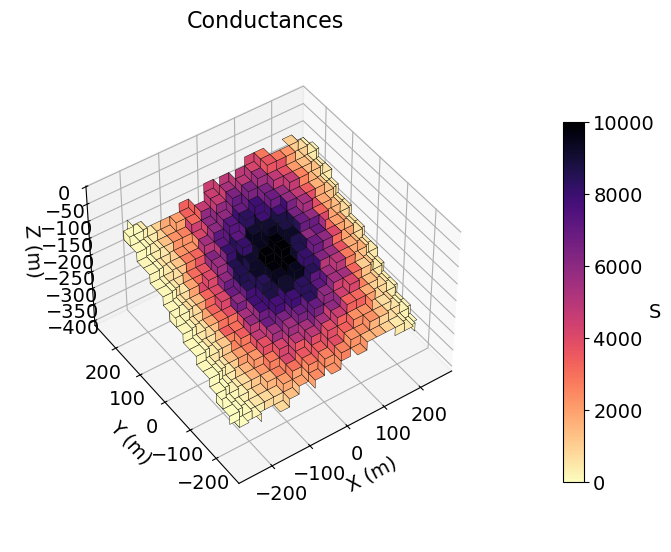

In [60]:
poly_faces = Poly3DCollection(poly_pts)
poly_colors = cmap(norm(temp_conds[temp_inds]))
poly_faces.set_facecolor(poly_colors)
poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_faces.set_linewidth(0.3)

fig = plt.figure(figsize=(7, 6))
ax1 = fig.add_axes([0.05, 0.1, 0.75, 0.85], projection="3d")
ax2 = fig.add_axes([0.85, 0.2, 0.03, 0.6])

ax1.add_collection3d(poly_faces)
ax1.set_box_aspect(aspect=None, zoom=0.8)
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_zlabel("Z (m)", labelpad=10)
ax1.set_title("Conductances", fontsize=16, pad=-20)
ax1.view_init(elev=45.0, azim=-125)

cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.magma_r
)
cbar.set_label("S", rotation=0, labelpad=0)

plt.show()

```{admonition} Warning
:class: caution
In this tutorial, we reuse the survey object from ou
```

In [54]:
simulation_dlny = tdem.simulation.Simulation3DHierarchicalElectricField(
    mesh,
    survey=survey,
    sigma=background_conductivity,
    tauMap=dlny_conductance_map,
    solver=get_default_solver()
)
simulation_dlny.time_steps = time_steps
simulation_dlny.t0 = t0

In [55]:
dpred_dlny = simulation_dlny.dpred(dlny_conductance_model)

In [56]:
b_dlny = (period / 4) * np.reshape(dpred_dlny, (n_comp, n_times, n_rx))

In [57]:
u_dlny = 100 * (b_dlny[0, :, :] - b_0[0, :, :]) / b_p
v_dlny = 100 * (b_dlny[1, :, :] - b_0[1, :, :]) / b_p
a_dlny = 100 * (b_dlny[2, :, :] - b_0[2, :, :]) / b_p

data_dlny = [u_dlny, v_dlny, a_dlny]

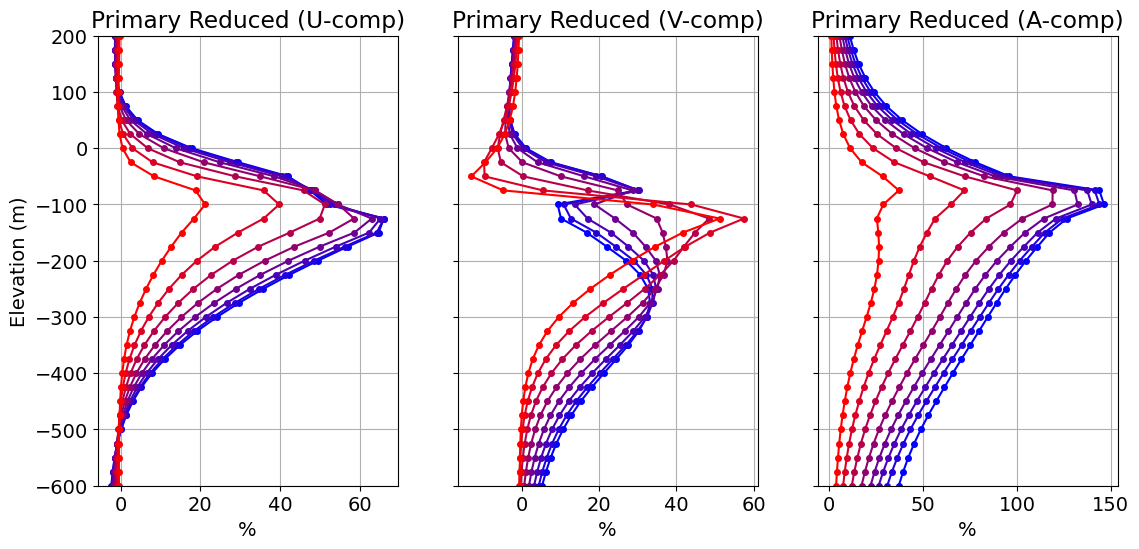

In [58]:
fig = plt.figure(figsize=(12, 6))
ax1 = [fig.add_axes([0.05 + 0.3 * ii, 0.2, 0.25, 0.75]) for ii in range(0, 3)]

comp_list = ["U", "V", "A"]

for ii in range(0, 3):
    d_temp = data_dlny[ii]

    for jj in range(n_times):
        ax1[ii].plot(
            d_temp[jj, :],
            receiver_locations[:, 2],
            marker="o",
            color=[jj / (n_times - 1), 0, 1 - jj / (n_times - 1)],
            markersize=4,
            label="_nolegend_",
        )

    ax1[ii].grid()
    ax1[ii].ticklabel_format(axis="both", scilimits=(0, 3))
    ax1[ii].set_xlabel("%")
    ax1[ii].set_ylim([s_min, s_max])
    if ii == 0:
        ax1[ii].set_ylabel("Elevation (m)")
    else:
        ax1[ii].set_yticklabels([])
    ax1[ii].set_title("Primary Reduced ({}-comp)".format(comp_list[ii]))

plt.show(fig)